***Tareas a realizar:***

***1.    Cargar el conjunto de datos en una estructura adecuada para su manipulación.***

In [1]:
# 1. CARGA DE DATOS
#---------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si usás archivo CSV (ejemplo: autos.csv)
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 3\Automobile.csv")

# Vista inicial
print(df.head())


                        name   mpg  cylinders  displacement  horsepower  \
0  chevrolet chevelle malibu  18.0          8         307.0       130.0   
1          buick skylark 320  15.0          8         350.0       165.0   
2         plymouth satellite  18.0          8         318.0       150.0   
3              amc rebel sst  16.0          8         304.0       150.0   
4                ford torino  17.0          8         302.0       140.0   

   weight  acceleration  model_year origin  
0    3504          12.0          70    usa  
1    3693          11.5          70    usa  
2    3436          11.0          70    usa  
3    3433          12.0          70    usa  
4    3449          10.5          70    usa  


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object 
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


In [3]:
print(df.dtypes)

name             object
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
dtype: object


***2.   Crear un gráfico de dispersión para visualizar las relaciones entre los pares de características numéricas `mpg` y `weight`.***

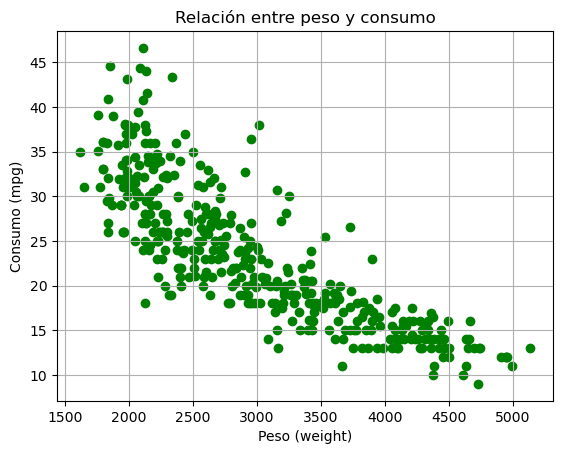

In [4]:
# 2. GRÁFICO DE DISPERSIÓN (mpg vs weight)
# ===============================
plt.figure()
plt.scatter(df['weight'], df['mpg'], color= 'green')
plt.xlabel('Peso (weight)')
plt.ylabel('Consumo (mpg)')
plt.title('Relación entre peso y consumo')
plt.grid()
plt.show()


### Relación entre peso y consumo

El gráfico de dispersión muestra una relación negativa entre el peso del vehículo y el consumo de combustible (mpg).

A medida que aumenta el peso, el rendimiento en millas por galón disminuye. Esto indica que los vehículos más pesados tienden a consumir más combustible.

Además, se observa que la relación es bastante clara y consistente, lo que sugiere una correlación significativa entre ambas variables.

También se puede notar una mayor dispersión en los vehículos más livianos, mientras que los más pesados presentan valores más concentrados en consumos bajos.

***3.   Generar un histograma del consumo de combustible (`mpg`) para analizar su distribución.***

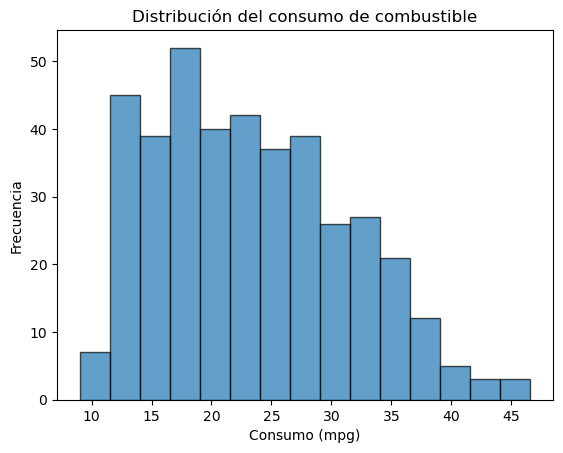

In [5]:
# 3. GRÁFICO HISTOGRAMA(mpg)
# ===============================
plt.figure()
plt.hist(df['mpg'], bins=15, edgecolor="black", alpha=0.7)
plt.xlabel('Consumo (mpg)')
plt.ylabel('Frecuencia')
plt.title('Distribución del consumo de combustible')
#plt.grid()
plt.show()


### Distribución del consumo de combustible

En el histograma se observa cómo se distribuyen los valores de consumo (mpg) de los vehículos.

La mayoría de los valores se concentran entre aproximadamente 15 y 30 mpg, lo que indica que ese es el rango más frecuente de consumo.

Se puede notar una leve asimetría hacia la derecha, ya que hay algunos valores más altos (por encima de 35 mpg), pero en menor cantidad.

Esto sugiere que existen pocos vehículos muy eficientes en consumo, mientras que la mayoría tiene un rendimiento medio.

***4.   Graficar un diagrama de caja (boxplot) de las características `cylinders` y `origin` para identificar posibles valores atípicos.***

<Figure size 1000x600 with 0 Axes>

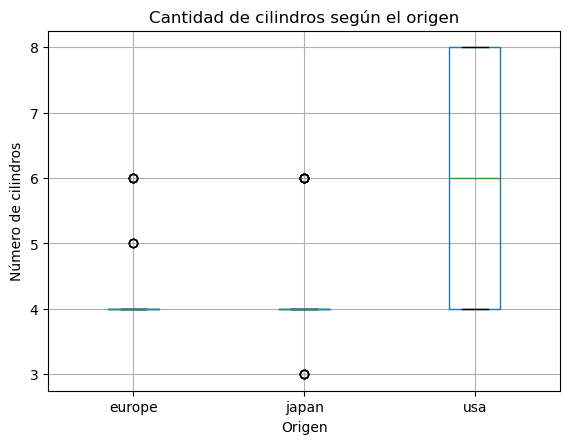

In [6]:
# 4. DIAGRAMA DE CAJA(BOXPLOT)
# ===============================
plt.figure(figsize=(10,6))
df.boxplot(column='cylinders', by='origin')
plt.title('Cantidad de cilindros según el origen')
plt.suptitle('')
plt.xlabel('Origen')
plt.ylabel('Número de cilindros')
#plt.grid()
plt.show()


***Análisis del gráfico***

*Europa*

La mayoría de los autos están en 4 cilindros (caja muy comprimida).
Aparecen valores en 5 y 6 cilindros como puntos separados.
Estos son posibles outliers, porque se alejan del comportamiento principal.

*Japón*

También se concentra en 4 cilindros.
Aparece un valor en 3 cilindros y otro en 6 cilindros.
Ambos pueden considerarse valores atípicos, especialmente el de 3 cilindros, que es poco común.

*Estados Unidos (USA)*

Hay mayor variabilidad: entre 4 y 8 cilindros.
La mediana está alrededor de 6 cilindros.
No se observan outliers claros, porque todos los valores están dentro del rango esperado.

“El boxplot muestra que los valores atípicos se presentan principalmente en Europa y Japón, donde algunos vehículos tienen una cantidad de cilindros diferente a la tendencia principal de 4 cilindros. En cambio, en Estados Unidos hay mayor variabilidad, pero sin valores atípicos marcados, lo que indica una distribución más amplia y esperada.”

***5.   Realizar un gráfico de barras que muestre la distribución de automóviles según su año de modelo (`model_year`) y origen (`origin`).***

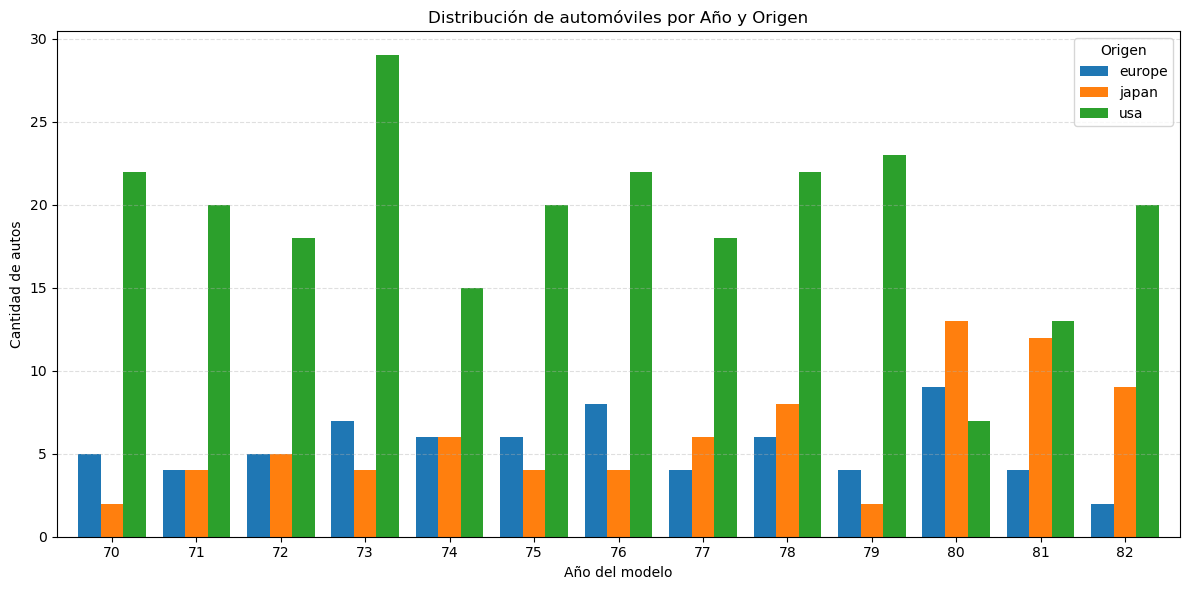

In [7]:
# Agrupar datos
conteo = df.groupby(['model_year', 'origin']).size().unstack()

# Graficar
conteo.plot(kind='bar', figsize=(12,6),width=0.8)
plt.title('Distribución de automóviles por Año y Origen')
plt.xlabel('Año del modelo')
plt.ylabel('Cantidad de autos')
plt.legend(title='Origen')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


***Análisis del gráfico***

“El gráfico muestra la evolución de la cantidad de automóviles según su origen a lo largo de los años. Estados Unidos domina ampliamente en la mayoría del período, mientras que Japón presenta un crecimiento sostenido hacia los últimos años. Europa, en cambio, mantiene una participación más estable sin grandes variaciones.”

Se puede observar un cambio en la tendencia del mercado, donde Japón comienza a ganar participación hacia los años más recientes del dataset.”
